<a href="https://colab.research.google.com/github/Alhmmada/Bike-Sharing-Demand-Prediction/blob/main/Assignment_1_Regression_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Assignment 1: Demand prediction of bike sharing system**

Bike sharing services are nowadays spread all over the world. They are beneficial for cities as they offer a climate neutral and healthy way of transportation. Moreover, similar to e-scooters, for the companies and transportation researchers they generate valuable data. This includes the trip route, trip origins and destinations, duration, and much more.

In this assignment we use a public bike sharing dataset from Washington, D.C., USA. published by Fanaee-T, H. (2013). Bike Sharing [Dataset]. UCI Machine Learning Repository. https://doi.org/10.24432/C5W894.

## Your Task

Your task in this assignment is:

1) to predict the demand of hourly rentals (**target-column: cnt**) using the [XGBoost](https://xgboost.readthedocs.io/en/stable/) and linear regression model. In this notebook we have provided you with the basic structure how to approach the problem. Feel free to reuse and improve parts of the exercise material.

2) After you have created the model please upload your code to Github and post the link to the notebook in the corresponding forum for the assignment with a short text describing how you have solved the task.

## Load data

You can also find more information about the data and the columns at: https://archive.ics.uci.edu/dataset/275/bike+sharing+dataset

In [2]:
import pandas as pd

url = 'https://raw.githubusercontent.com/zhenliangma/Applied-AI-in-Transportation/master/Exercise_2_regression_model/Exercise2BikeSharing.csv'
df = pd.read_csv(url)

#df = pd.read_csv('Exercise2BikeSharing.csv')
#df.head(10)

In [3]:
df.shape

(17379, 17)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     17379 non-null  int64  
 1   dteday      17379 non-null  object 
 2   season      17379 non-null  int64  
 3   yr          17379 non-null  int64  
 4   mnth        17379 non-null  int64  
 5   hr          17379 non-null  int64  
 6   holiday     17379 non-null  int64  
 7   weekday     17379 non-null  int64  
 8   workingday  17379 non-null  int64  
 9   weathersit  17379 non-null  int64  
 10  temp        17379 non-null  float64
 11  atemp       17379 non-null  float64
 12  hum         17379 non-null  float64
 13  windspeed   17379 non-null  float64
 14  casual      17379 non-null  int64  
 15  registered  17379 non-null  int64  
 16  cnt         17379 non-null  int64  
dtypes: float64(4), int64(12), object(1)
memory usage: 2.3+ MB


## Train / Test split
- Target: `cnt` (count of total rental bikes including both casual and registered)
- Predictors: weather (`temp`, `atemp`, `hum`, `windspeed`, `weathersit`), calendar (`hr`, `weekday`, `workingday`, `holiday`, `season`), and `yr`.
- We keep it simple; you can expand features (e.g., interactions) later.

In [5]:
from sklearn.model_selection import train_test_split
target = 'cnt'

X = df.copy()
y = df[target].astype(float)

X.drop(columns=[target], inplace=True)

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


## Data Processing / Feature Engineering

Before training the model think about data processing and feature engineering steps if applicable, such as:
- adding/removal of features
- normalization
- one hot encoding
- ...


In [8]:
X = df.copy()
y = df['cnt'].astype(float)

X = X.drop(columns=['cnt', 'instant', 'dteday', 'casual', 'registered'])

In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

## Hyperparameter optimization
Hyperparameter tuning helps find the best set of hyperparameters for your model. Use Grid Search or Random Search with Cross Validation from scikit-learn to search for the best combination of parameters.

In [11]:
# Your code here
from xgboost import XGBRegressor
from sklearn.model_selection import RandomizedSearchCV

xgb = XGBRegressor(random_state=42)

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1]
}

random_search = RandomizedSearchCV(
    xgb,
    param_distributions=param_grid,
    n_iter=10,
    cv=3,
    scoring='neg_mean_squared_error',
    random_state=42
)

random_search.fit(X_train, y_train)

print(random_search.best_params_)

{'n_estimators': 300, 'max_depth': 7, 'learning_rate': 0.05}


## Train the XGBoost and Linear regression models
Now, create an XGBoost and linear regression model using the best parameters and train them using the training data.

In [12]:
# Your code here
from sklearn.linear_model import LinearRegression

xgb_model = random_search.best_estimator_

linear_model = LinearRegression()
linear_model.fit(X_train, y_train)


LinearRegression()

In [13]:
from sklearn.linear_model import LinearRegression

In [14]:
xgb_model = random_search.best_estimator_

In [15]:
linear_model = LinearRegression()

In [16]:
linear_model.fit(X_train, y_train)

LinearRegression()

## Make predictions
Use the trained models to make predictions on the test data and compare the performance of the XGBoost and linear regression models using metrics like Mean Squared Error (MSE) and R-squared.

In [17]:
# Your code here
y_pred_xgb = xgb_model.predict(X_test)
y_pred_lr = linear_model.predict(X_test)

In [18]:
y_pred_xgb = xgb_model.predict(X_test)

In [19]:
y_pred_lr = linear_model.predict(X_test)

In [20]:
from sklearn.metrics import mean_squared_error, r2_score

mse_xgb = mean_squared_error(y_test, y_pred_xgb)
r2_xgb = r2_score(y_test, y_pred_xgb)

mse_lr = mean_squared_error(y_test, y_pred_lr)
r2_lr = r2_score(y_test, y_pred_lr)

print("XGBoost")
print("MSE:", mse_xgb)
print("R²:", r2_xgb)

print("\nLinear Regression")
print("MSE:", mse_lr)
print("R²:", r2_lr)

XGBoost
MSE: 1513.0562977458906
R²: 0.9522173806091099

Linear Regression
MSE: 19379.828367651717
R²: 0.38798115831391344


## Visualize the predictions and compare the mdoels
Create a "Actual vs. Predicted Values" graph to give a visual inspection of the prediction quality.

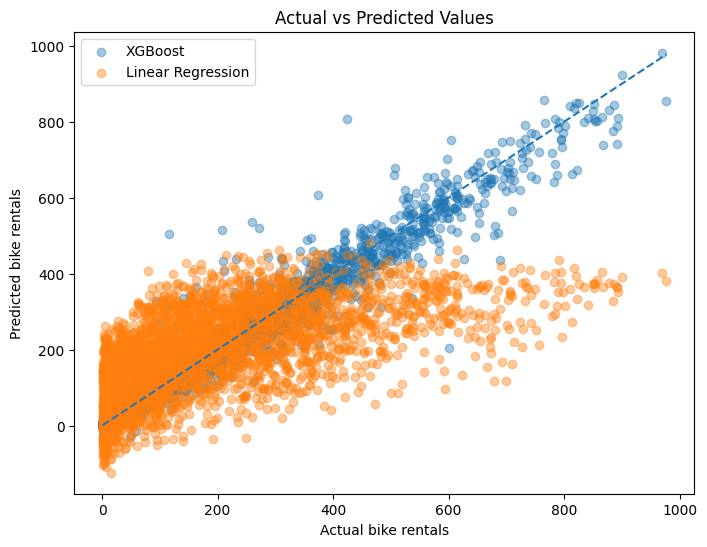

In [21]:
# Your Code here
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred_xgb, alpha=0.4, label='XGBoost')
plt.scatter(y_test, y_pred_lr, alpha=0.4, label='Linear Regression')

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle='--'
)

plt.xlabel('Actual bike rentals')
plt.ylabel('Predicted bike rentals')
plt.title('Actual vs Predicted Values')

plt.legend()
plt.show()

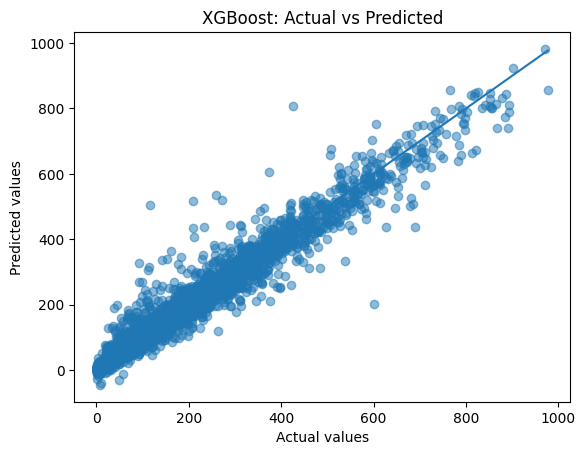

In [22]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred_xgb, alpha=0.5)
plt.xlabel("Actual values")
plt.ylabel("Predicted values")
plt.title("XGBoost: Actual vs Predicted")
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()])
plt.show()

In [26]:
# y_pred_linear = linear_model.predict(X_test)

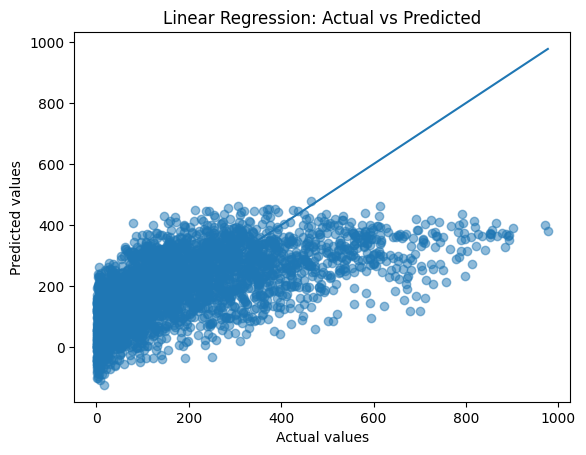

In [27]:
plt.scatter(y_test, y_pred_linear, alpha=0.5)
plt.xlabel("Actual values")
plt.ylabel("Predicted values")
plt.title("Linear Regression: Actual vs Predicted")

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()]
)

plt.show()

The aim of this assignment was to predict hourly bike rental demand using XGBoost and Linear Regression. The dataset was first prepared by removing columns that should not be used as predictors, such as cnt, instant, dteday, casual, and registered. The data was then divided into training and test sets.

For the XGBoost model, RandomizedSearchCV with cross-validation was used to find suitable hyperparameters. The best model used 300 estimators, a maximum depth of 7, and a learning rate of 0.05.

The results showed a clear difference between the two models. XGBoost achieved an MSE of 1513.06 and an R² of 0.952, while Linear Regression achieved an MSE of 19379.83 and an R² of 0.388. The prediction plots also showed that the XGBoost predictions were much closer to the actual values. Therefore, XGBoost performed significantly better and was more suitable for predicting bike-sharing demand in this dataset.
